In [2]:
!pip install names
import pandas as pd
import numpy as np
import os
import random
import names
import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.1/789.1 kB 34.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for names: filename=names-0.3.0-py3-none-any.whl size=803681 sha256=b5ad8637880d1eac47314f886b9bf9e27e0f68876d23a79d08859a1bcc913f3c
  Stored in directory: /root/.cache/pip/wheels/8d/db/fc/50ec19a89a8dcbbd158a4aae44123cb525cda1f07dae287197
Successfully built names


In [3]:
df = pd.read_excel('Dmart.xlsx')
df.shape

(6428, 18)

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales (shipping price included)', 'Profit',
       'Quantity'],
      dtype='object')

In [8]:
df.rename(columns = {'Sales (shipping price included)' : 'Sales'}, inplace = True)

In [ ]:
# df.duplicated() # return boolean series , df index as series index
# ?df.duplicated # return boolean series denotes duplicate rows

df_dc = pd.DataFrame(data={'A': [1,2,3,4], 'B': [1,2,3,4], 'C': [1,2,3,4]}, index=['i','ii','iii','iv'])
print(df_dc)
# remove duplicate columns
df_dc.T[~df_dc.T.duplicated()].T



     A  B  C
i    1  1  1
ii   2  2  2
iii  3  3  3
iv   4  4  4


,A
i,1
ii,2
iii,3
iv,4


In [ ]:
df.head(2)

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales,Profit,Quantity
0,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,1205.000000,866.294118,870.294118,334.705882,-1.0,869.294118,4.0,1
1,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,320.823529,323.823529,204.411765,1.0,324.823529,3.0,1


In [ ]:
# df = pd.concat([df, pd.DataFrame(data={'D': [1,2,3,4]})])
# df[df.columns.]
# df.columns.
# df_dc['C'].astype(str)
# df_dc['C']
# df_dc.info()

# df_dc.join(pd.DataFrame(pd.Series([1, 2, 3, 4], index=['A1','B1','C1','D1'], name=1)).T, how='inner')
# pd.concat([df_dc, pd.Series([3,4,5,6]), pd.Series([9, 0, 2, 3])])
# Series are always treated as CLOUMN in pandas
# transposing the series always same with original series, no use in transpose in series.


# how to add new index and new column in a data frame
# pd.Series([2,3,4,5], name='A').T.eq(pd.Series([2,3,4,5], name='A'))
# pd.DataFrame(data={'A':5, 'B':6, 'C':7}, index=[5])

# for add new row concat df created using dict with scalar value as value and column as key,
# and give index constant and aslo ignore index, axis=0 is default
pd.concat(objs=[df_dc, pd.DataFrame(data={'A':5, 'B':6, 'C':7}, index=[5])], ignore_index=True)

# for add new column just concat a series
pd.concat(objs=[df_dc, pd.Series([4,5,6,7], name='D').astype(int)], axis=1)
# pd.concat(objs=[df_dc, ], axis=0)

# ?pd.concat


,A,B,C
0,1,1,1
1,2,2,2
2,3,3,3
3,4,4,4
4,5,6,7


In [9]:
reg_df = df.groupby('Region', as_index = False)['Sales'].sum().round(2)
reg_df

# df_reg = df.groupby(by=['Region'], as_index=False)[].

,Region,Sales
0,Central Asia,2632621.12
1,North Asia,2698224.13
2,Southeast Asia,230874.94


# Pie Chart

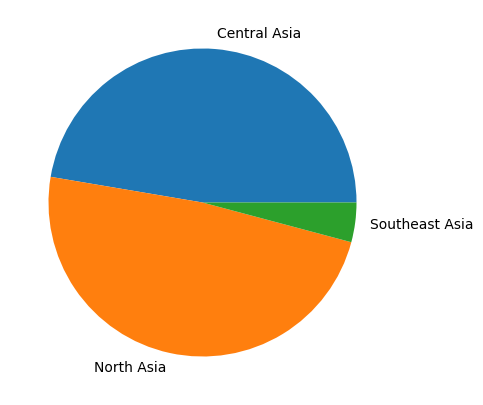

In [ ]:
plt.figure(figsize = (10, 5))
plt.pie(reg_df['Sales'], labels = reg_df['Region']);

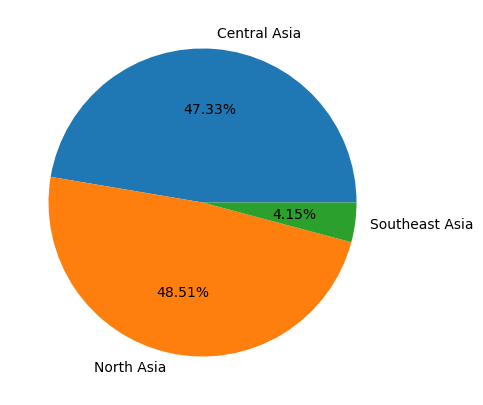

In [ ]:
plt.figure(figsize = (10, 5))
plt.pie(reg_df['Sales'], labels = reg_df['Region'], autopct = "%1.2f%%");

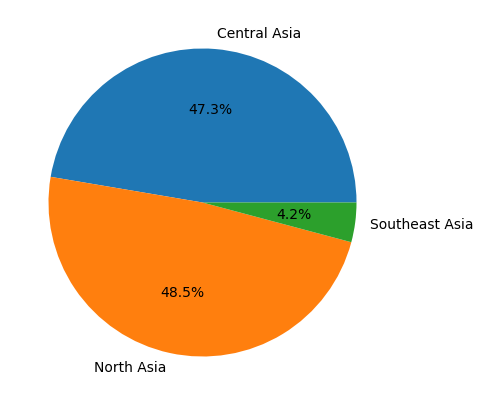

In [ ]:
plt.figure(figsize = (10, 5))
plt.pie(reg_df['Sales'], labels = reg_df['Region'], autopct = "%1.1f%%");

# Violin Plot

In [ ]:
df['Sales'].describe()

count     6428.000000
mean       865.233384
std       2639.154865
min          4.529412
25%         80.333333
50%        140.441176
75%        391.028056
max      42854.863900
Name: Sales, dtype: float64

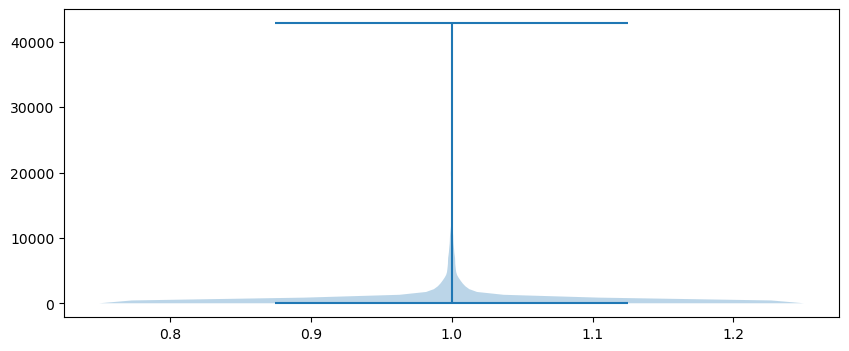

In [ ]:
plt.figure(figsize = (10, 4))
plt.violinplot(df['Sales']);

In [ ]:
df['Sales'].shape

(6428,)

In [ ]:
len(df[df['Sales'] > 800])

1087

In [ ]:
len(df[df['Sales'] > 10000])

98

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales', 'Profit', 'Quantity'],
      dtype='object')

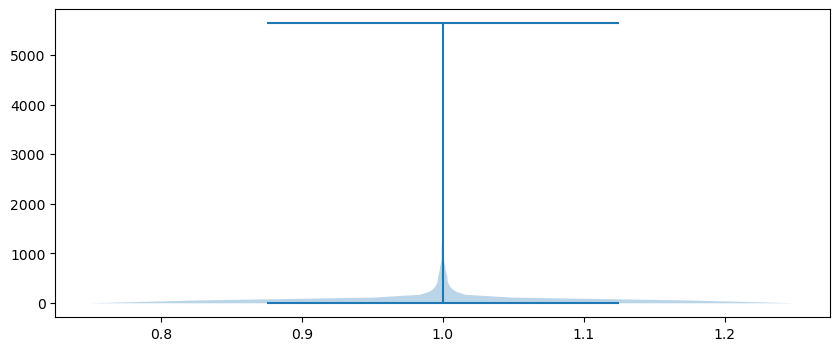

In [ ]:
plt.figure(figsize = (10, 4))
plt.violinplot(df['Shipping Cost']);

# Distribution Plot

In [ ]:
x = np.arange(0, 10, 0.2)
y = np.sin(x)

In [ ]:
print(x)

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6.  6.2 6.4 6.6 6.8 7.
 7.2 7.4 7.6 7.8 8.  8.2 8.4 8.6 8.8 9.  9.2 9.4 9.6 9.8]


In [ ]:
print(y)

[ 0.          0.19866933  0.38941834  0.56464247  0.71735609  0.84147098
  0.93203909  0.98544973  0.9995736   0.97384763  0.90929743  0.8084964
  0.67546318  0.51550137  0.33498815  0.14112001 -0.05837414 -0.2555411
 -0.44252044 -0.61185789 -0.7568025  -0.87157577 -0.95160207 -0.993691
 -0.99616461 -0.95892427 -0.88345466 -0.77276449 -0.63126664 -0.46460218
 -0.2794155  -0.0830894   0.1165492   0.31154136  0.49411335  0.6569866
  0.79366786  0.8987081   0.96791967  0.99854335  0.98935825  0.94073056
  0.85459891  0.7343971   0.58491719  0.41211849  0.22288991  0.02477543
 -0.17432678 -0.36647913]


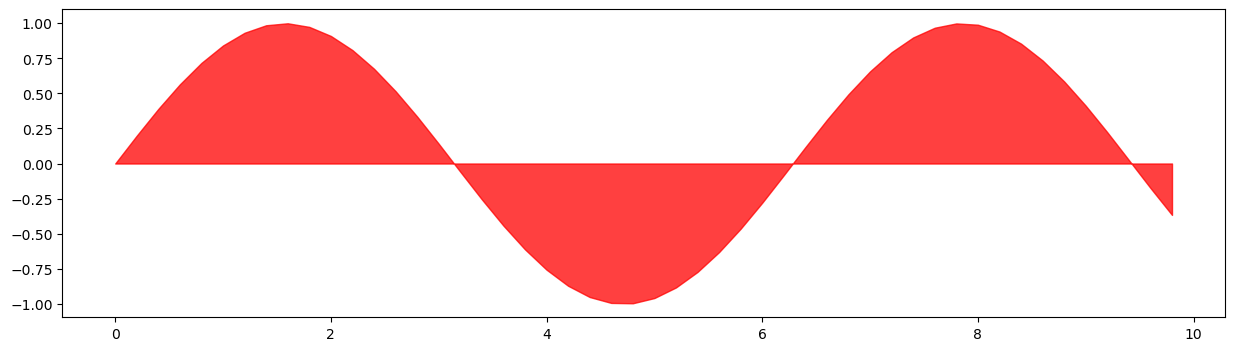

In [ ]:
plt.figure(figsize = (15, 4))
plt.fill_between(x, y, alpha = 0.75 , color = 'r');

# Seaborn

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales', 'Profit', 'Quantity'],
      dtype='object')

In [ ]:
df.dtypes

Order Date                      datetime64[ns]
Order Priority                          object
Ship Type                               object
City                                    object
State                                   object
Country                                 object
Region                                  object
Segment                                 object
Super Category                          object
Category                                object
Price                                  float64
Operational/ Production Cost           float64
Selling Price                          float64
Discount                               float64
Shipping Cost                          float64
Sales                                  float64
Profit                                 float64
Quantity                                 int64
dtype: object

In [ ]:
df.head()

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales,Profit,Quantity
0,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,1205.000000,866.294118,870.294118,334.705882,-1.0,869.294118,4.0,1
1,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,320.823529,323.823529,204.411765,1.0,324.823529,3.0,1
2,2015-01-02,Moderate,Named Day,Chongqing,Chongqing,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,215.686275,142.098039,145.098039,70.588235,0.0,145.098039,3.0,1
3,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,318.823529,323.823529,204.411765,0.0,323.823529,5.0,1
4,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,137.450980,71.372549,76.372549,61.078431,1.0,77.372549,5.0,1


In [ ]:
pd.DatetimeIndex(df['Order Date']).month_name()

Index(['January', 'January', 'January', 'January', 'January', 'January',
       'January', 'January', 'January', 'January',
       ...
       'December', 'December', 'December', 'December', 'December', 'December',
       'December', 'December', 'December', 'December'],
      dtype='object', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).month

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).quarter

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).year

Index([2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015, 2015,
       ...
       2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018, 2018],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).day

Index([ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
      dtype='int32', name='Order Date', length=6428)

In [ ]:
pd.DatetimeIndex(df['Order Date']).day_name()

Index(['Friday', 'Friday', 'Friday', 'Friday', 'Friday', 'Friday', 'Friday',
       'Friday', 'Friday', 'Friday',
       ...
       'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday',
       'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday', 'Wednesday'],
      dtype='object', name='Order Date', length=6428)

In [ ]:
?pd.DatetimeIndex(df['Order Date']).dayofweek

Object `pd.DatetimeIndex(df['Order Date']).dayofweek` not found.


In [ ]:
# type(
pd.DatetimeIndex(df['Order Date']).isocalendar().reset_index()
    #  .isocalendar().week

,Order Date,year,week,day
0,2015-01-02,2015,1,5
1,2015-01-02,2015,1,5
2,2015-01-02,2015,1,5
3,2015-01-02,2015,1,5
4,2015-01-02,2015,1,5
...,...,...,...,...
6423,2018-12-12,2018,50,3
6424,2018-12-12,2018,50,3
6425,2018-12-12,2018,50,3
6426,2018-12-12,2018,50,3


In [ ]:
# df['Month'] = pd.DatetimeIndex(df['Order Date']).month_name()
# df['Month_no'] = pd.DatetimeIndex(df['Order Date']).month
# df['Year'] = pd.DatetimeIndex(df['Order Date']).year

df['Month'] = pd.DatetimeIndex(df['Order Date']).month_name()
df['Month_no'] = pd.DatetimeIndex(df['Order Date']).month
df['Year'] = pd.DatetimeIndex(df['Order Date']).year


In [ ]:
# test = df.groupby(['Month', 'Year'], as_index = False)['Sales'].sum()
# test['Year'] = test['Year'].astype('str')
# test['Month'] + '-' + test['Year'].str[-2:]
# test['Year'].astype('str').str[2:]
test['Year'].astype('str').str[-2:]

,Year
0,15
1,16
2,17
3,18
4,15
5,16
6,17
7,18
8,15
9,16


# Monthly Sales Trend

In [5]:
df['Month'] = pd.DatetimeIndex(df['Order Date']).month_name()
df['Month_no'] = pd.DatetimeIndex(df['Order Date']).month

In [10]:
trend = df.groupby(['Month', 'Month_no'], as_index = False)['Sales'].sum().round(2)

In [ ]:
trend = trend.sort_values(by = 'Month_no').reset_index(drop = True)
# trend['Month'] = trend['Month'].str[:3]
trend

,Month,Month_no,Sales
0,January,1,541875.59
1,February,2,562972.54
2,March,3,373412.25
3,April,4,531443.16
4,May,5,323981.94
5,June,6,514447.06
6,July,7,508245.15
7,August,8,398355.13
8,September,9,369082.92
9,October,10,323740.87


In [ ]:
trend

,Month,Month_no,Sales
0,April,4,531443.16
1,August,8,398355.13
2,December,12,572773.27
3,February,2,562972.54
4,January,1,541875.59
5,July,7,508245.15
6,June,6,514447.06
7,March,3,373412.25
8,May,5,323981.94
9,November,11,541390.29


## Line Chart

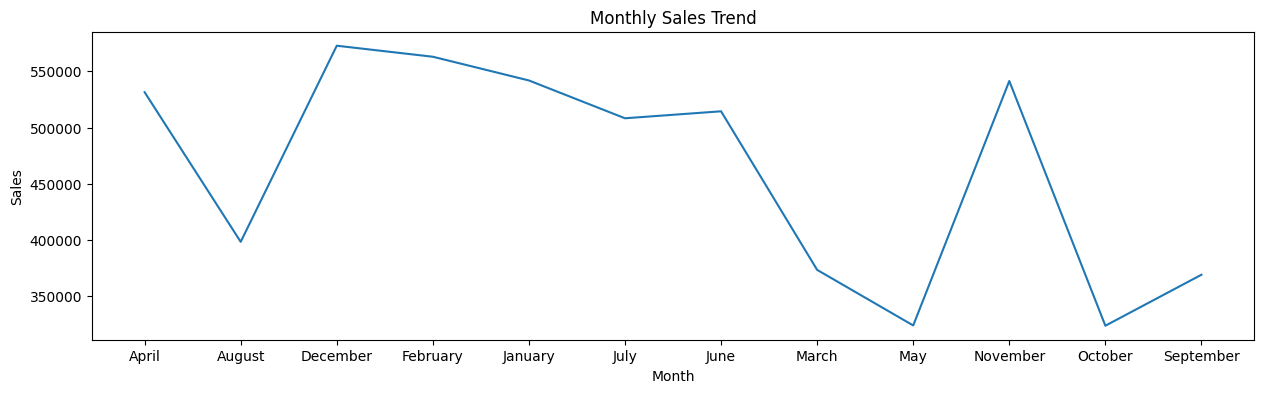

In [11]:
plt.figure(figsize = (15, 4))
plt.title("Monthly Sales Trend")
sns.lineplot(x = 'Month', y = 'Sales', data = trend);

# Colors

‘Accent’, ‘Accent_r’, ‘Blues’, ‘Blues_r’, ‘BrBG’, ‘BrBG_r’, ‘BuGn’, ‘BuGn_r’, ‘BuPu’, ‘BuPu_r’, ‘CMRmap’, ‘CMRmap_r’, ‘Dark2’, ‘Dark2_r’, ‘GnBu’, ‘GnBu_r’,  ‘Greens’, ‘Greens_r’, ‘Greys’, ‘Greys_r’, ‘OrRd’, ‘OrRd_r’, ‘Oranges’, ‘Oranges_r’,  ‘PRGn’, ‘PRGn_r’, ‘Paired’, ‘Paired_r’, ‘Pastel1’, ‘Pastel1_r’, ‘Pastel2’,  ‘Pastel2_r’, ‘PiYG’, ‘PiYG_r’, ‘PuBu’, ‘PuBuGn’, ‘PuBuGn_r’, ‘PuBu_r’, ‘PuOr’, ‘PuOr_r’, ‘PuRd’, ‘PuRd_r’, ‘Purples’, ‘Purples_r’, ‘RdBu’, ‘RdBu_r’, ‘RdGy’, ‘RdGy_r’, ‘RdPu’, ‘RdPu_r’, ‘RdYlBu’, ‘RdYlBu_r’, ‘RdYlGn’, ‘RdYlGn_r’, ‘Reds’, ‘Reds_r’, ‘Set1’, ‘Set1_r’, ‘Set2’, ‘Set2_r’, ‘Set3’, ‘Set3_r’, ‘Spectral’, ‘Spectral_r’, ‘Wistia’, ‘Wistia_r’, ‘YlGn’, ‘YlGnBu’, ‘YlGnBu_r’, ‘YlGn_r’, ‘YlOrBr’, ‘YlOrBr_r’, ‘YlOrRd’, ‘YlOrRd_r’, ‘afmhot’, ‘afmhot_r’, ‘autumn’, ‘autumn_r’, ‘binary’, ‘binary_r’,  ‘bone’, ‘bone_r’, ‘brg’, ‘brg_r’, ‘bwr’, ‘bwr_r’, ‘cividis’, ‘cividis_r’, ‘cool’, ‘cool_r’,  ‘coolwarm’, ‘coolwarm_r’, ‘copper’, ‘copper_r’, ‘cubehelix’, ‘cubehelix_r’, ‘flag’, ‘flag_r’,  ‘gist_earth’, ‘gist_earth_r’, ‘gist_gray’, ‘gist_gray_r’, ‘gist_heat’, ‘gist_heat_r’, ‘gist_ncar’,  ‘gist_ncar_r’, ‘gist_rainbow’, ‘gist_rainbow_r’, ‘gist_stern’, ‘gist_stern_r’, ‘gist_yarg’,  ‘gist_yarg_r’, ‘gnuplot’, ‘gnuplot2’, ‘gnuplot2_r’, ‘gnuplot_r’, ‘gray’, ‘gray_r’, ‘hot’, ‘hot_r’,  ‘hsv’, ‘hsv_r’, ‘icefire’, ‘icefire_r’, ‘inferno’, ‘inferno_r’, ‘jet’, ‘jet_r’, ‘magma’, ‘magma_r’,  ‘mako’, ‘mako_r’, ‘nipy_spectral’, ‘nipy_spectral_r’, ‘ocean’, ‘ocean_r’, ‘pink’, ‘pink_r’,  ‘plasma’, ‘plasma_r’, ‘prism’, ‘prism_r’, ‘rainbow’, ‘rainbow_r’, ‘rocket’, ‘rocket_r’,  ‘seismic’, ‘seismic_r’, ‘spring’, ‘spring_r’, ‘summer’, ‘summer_r’, ‘tab10’, ‘tab10_r’,’tab20′, ‘tab20_r’, ‘tab20b’, ‘tab20b_r’, ‘tab20c’, ‘tab20c_r’, ‘terrain’, ‘terrain_r’, ‘turbo’,  ‘turbo_r’, ‘twilight’, ‘twilight_r’, ‘twilight_shifted’, ‘twilight_shifted_r’, ‘viridis’,  ‘viridis_r’, ‘vlag’, ‘vlag_r’, ‘winter’, ‘winter_r’

# Bar Chart

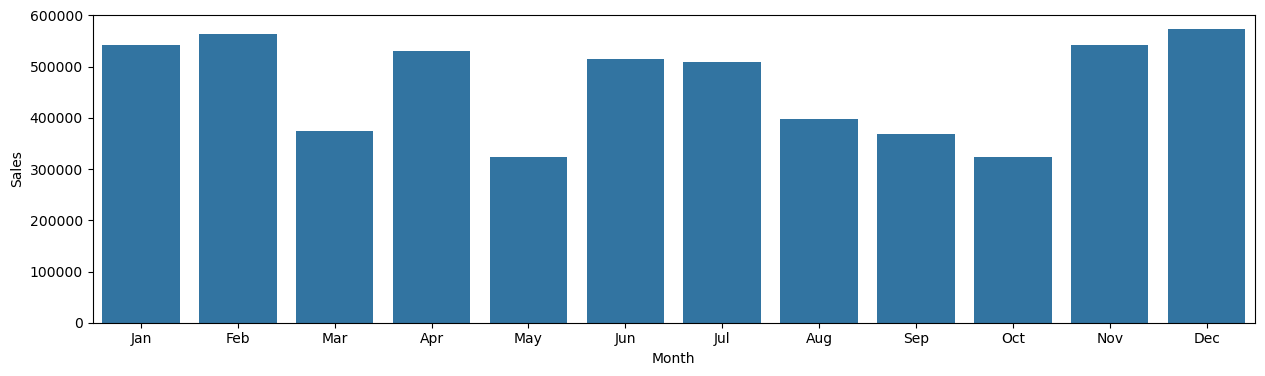

In [ ]:
plt.figure(figsize = (15, 4))
sns.barplot(x = 'Month', y = 'Sales', data = trend);

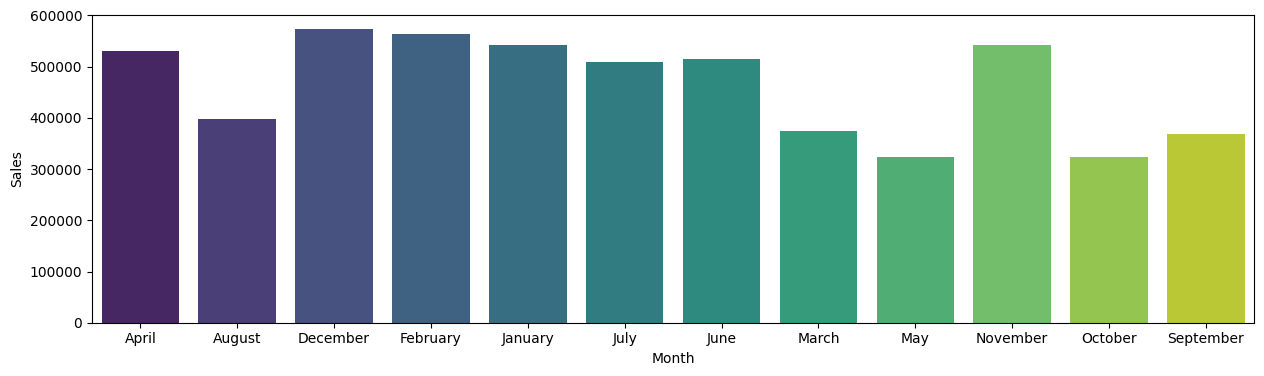

In [16]:
plt.figure(figsize = (15, 4))
sns.barplot(x = 'Month', y = 'Sales', data = trend, hue = 'Month', palette = 'viridis');

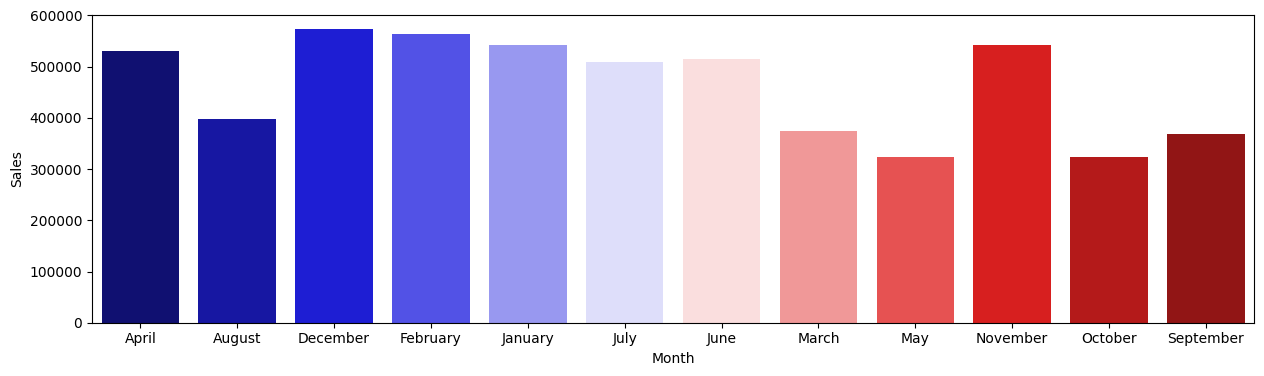

In [14]:
plt.figure(figsize = (15, 4))
sns.barplot(x = 'Month', y = 'Sales', data = trend, hue = 'Month', palette = 'seismic');

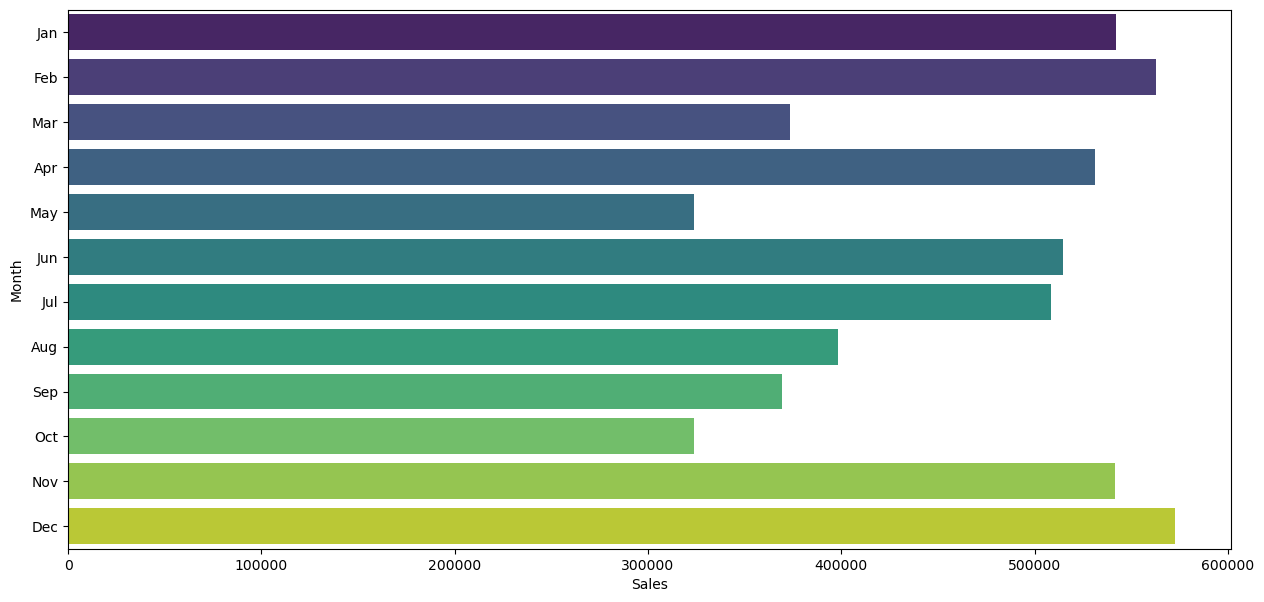

In [ ]:
plt.figure(figsize = (15, 7))
sns.barplot(y = 'Month', x = 'Sales', data = trend, hue = 'Month', palette = 'viridis');

In [ ]:
# lineplot different arguments
# day 5 and 6 video